# Used Car Price Prediction

**Objective:** Predict the selling price of used cars from their listing details (brand, model, year, mileage, engine, fuel type, accident history, etc.).

**Data**

| File | Rows | Description |
|------|------|-------------|
| `train.csv` | 3,207 | Car listings with their known `price` |
| `test.csv` | 802 | Car listings whose price must be predicted |

**Approach at a glance**

1. Clean the raw text fields and add new features, keeping every row.
2. Model the **logarithm** of price to handle its skew.
3. Encode categorical columns (target encoding for high-cardinality columns, ordinal codes for the rest).
4. Train two tree ensembles — **Histogram Gradient Boosting** and **Random Forest** — and average their predictions.
5. Estimate accuracy with **5-fold cross-validation**, then retrain on all data and predict the test set.

**Results (5-fold cross-validation on `train.csv`)**

| Model | MAE | R² (cars < $500k) | R² (log price) |
|-------|-----|-------------------|----------------|
| Histogram Gradient Boosting | $11,462 | 0.766 | 0.852 |
| Random Forest | $11,266 | 0.783 | 0.850 |
| **Blend (average of both)** | **$11,042** | **0.793** | **0.858** |

**Contents**

1. Setup
2. Load the Data
3. Data Cleaning & Feature Engineering
4. Exploring the Target Variable
5. Feature Selection
6. Preprocessing Pipeline
7. Model Definition
8. Model Evaluation (Cross-Validation)
9. Final Training & Test Predictions
10. Save Predictions
11. Conclusion

## 1. Setup

Import the libraries used throughout the notebook:

- **pandas / NumPy** — data loading, manipulation and numerical operations.
- **matplotlib** — charts for exploring the data and the results.
- **scikit-learn** — cross-validation, preprocessing (encoders, column transformer), the two regression models, pipelines and evaluation metrics.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OrdinalEncoder, TargetEncoder
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error

## 2. Load the Data

Read the training and test files and confirm their dimensions. The test set has one fewer column because it has no `price`.

In [14]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print('Train:', train.shape, '| Test:', test.shape)
train.head()

Train: (3207, 14) | Test: (802, 13)


,id,brand,model,model_year,milage,fuel_type,ext_col,int_col,accident,clean_title,price,engine_displacement_l,engine_cylinders,transmission_type
0,1,Lexus,IS 300 Base,2018,"50,992 mi.",Gasoline,White,Gray,At least 1 accident or damage reported,Yes,"$28,000",3.5,6.0,Automatic
1,2,Chevrolet,Impala Base,2004,"64,500 mi.",Gasoline,Beige,Beige,None reported,Yes,"$5,900",3.4,6.0,Automatic
2,3,RAM,2500 SLT,2017,"86,000 mi.",Diesel,Gray,Gray,At least 1 accident or damage reported,Yes,"$41,000",6.7,6.0,Automatic
3,4,Mercedes-Benz,SL-Class SL 550,2013,"24,933 mi.",Gasoline,Silver,Red,At least 1 accident or damage reported,Yes,"$40,250",4.6,8.0,Other
4,5,Ford,Shelby GT350R Base,2018,"18,500 mi.",Gasoline,Blue,Black,At least 1 accident or damage reported,Yes,"$77,999",5.2,8.0,Manual


## 3. Data Cleaning & Feature Engineering

A single `clean()` function is applied to both datasets so they are transformed identically. **No rows are removed** — missing values are filled or left for the models to handle, so every test car receives a prediction.

| Step | What it does |
|------|--------------|
| `milage` & `price` | Strip text and symbols using regular expressions and convert to integers (`"50,992 mi."` → `50992`, `"$28,000"` → `28000`) . |
| `accident` | `None reported` → 0, `At least 1 accident…` → 1 using map function; unknown values stay missing. |
| `clean_title` | The .eq() function converts it to a Boolean value and then we get `Yes` → 1, anything else (including missing) → 0. |
| `fuel_type` | Placeholder values (`–`, `not supported`) treated as missing and replaced by Nan. Cars with no fuel type **and** no cylinder count are labelled `Electric` (mostly Teslas and Rivians); other gaps become `Unknown`. |
| `car_age` | 2026 − `model_year`; a direct measure of depreciation. |
| `milage_per_year` | Mileage divided by age, showing how heavily the car was used. Here, the lowest age is considered as 1 so that there are no division errors. |
| `model_base` | Brand + first word of the model (`"IS 300 Base"` → `"Lexus IS"`), grouping trims into model families so unseen trims in the test set still match. |
| `price` | Checks if the dataframe has a column Price as train.csv has it but test.csv does not, then strips text and symbols using regular expressions and converts to integers. |
| `engine_displacement_l` | As passenger cars have an engine displacement well under 10.0 L, displacements above 10 L are decimal-point typos (e.g. 75 → 7.5 L) and are divided by 10. |
| `ext_col_base` and `int_col_base` | Only the last name of each colour is taken in lowercase (`"Twilight Blue Metallic"` → `"metallic"`), to add simplicity in reading complicated colour names. |

In [15]:
def clean(df):
    df = df.copy()
    df['milage'] = df['milage'].str.replace(r'[^0-9]', '', regex=True).astype(int)
    if 'price' in df.columns:
        df['price'] = df['price'].str.replace(r'[$,]', '', regex=True).astype(int)
    df['accident'] = df['accident'].map({'None reported': 0, 'At least 1 accident or damage reported': 1})
    df['clean_title'] = df['clean_title'].eq('Yes').astype(int)
    df['fuel_type'] = df['fuel_type'].replace({'–': np.nan, 'not supported': np.nan})
    df['is_electric'] = (df['fuel_type'].isna() & df['engine_cylinders'].isna()).astype(int)
    fuel_fill = pd.Series(np.where(df['is_electric'] == 1, 'Electric', 'Unknown'), index=df.index)
    df['fuel_type'] = df['fuel_type'].fillna(fuel_fill)
    df.loc[df['engine_displacement_l'] > 10, 'engine_displacement_l'] /= 10
    df['car_age'] = 2026 - df['model_year']
    df['milage_per_year'] = df['milage'] / df['car_age'].clip(lower=1)
    df['model_base'] = df['brand'] + ' ' + df['model'].str.split().str[0]
    df['ext_col_base'] = df['ext_col'].str.split().str[-1].str.lower()
    df['int_col_base'] = df['int_col'].str.split().str[-1].str.lower()
    return df

train = clean(train)
test = clean(test)

**Check:** the row counts are unchanged, and electric vehicles are now identified explicitly.

In [16]:
print('Train:', train.shape, '| Test:', test.shape)
train['fuel_type'].value_counts()

Train: (3207, 20) | Test: (802, 19)


fuel_type
Gasoline          2650
Electric           172
Hybrid             159
E85 Flex Fuel      109
Diesel              90
Plug-In Hybrid      27
Name: count, dtype: int64

## 4. Exploring the Target Variable

Car prices are heavily right-skewed: a few hypercars (up to about $2.9M) dominate the scale. Taking the logarithm produces a near-symmetric distribution that is much easier to model, since the extreme values are compressed. This lets the model learn *percentage* differences in price rather than absolute ones.

Skewness (raw price): 19.25
Skewness (log price): 0.15


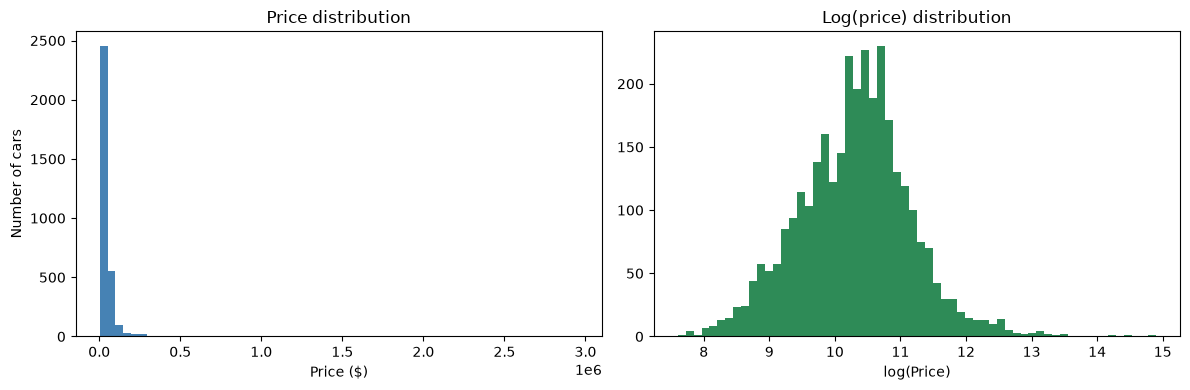

In [ ]:
print('Skewness (raw price):', round(train['price'].skew(), 2))
print('Skewness (log price):', round(np.log(train['price']).skew(), 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4)) #This creates two graphs next to each other, axes[0] refers to the left one and axes[1] to the right one
axes[0].hist(train['price'], bins=60, color='steelblue')
axes[0].set_title('Price distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Number of cars')
axes[1].hist(np.log(train['price']), bins=60, color='seagreen')
axes[1].set_title('Log(price) distribution')
axes[1].set_xlabel('log(Price)')
plt.tight_layout()
plt.show()

## 5. Feature Selection

Features are grouped by how they will be encoded:

- **Target-encoded** (`brand`, `model_base`, `model`) — text columns with many unique values; each category is replaced by its average log price.
- **Ordinal-encoded** (`fuel_type`, `transmission_type`, colour bases) — text columns with few unique values; each category receives an integer code.
- **Numeric** — used as-is. Tree-based models need no scaling and can handle missing values.

In [ ]:
target_enc_cols = ['brand', 'model_base', 'model']
ordinal_cols = ['fuel_type', 'transmission_type', 'ext_col_base', 'int_col_base']
numeric_cols = ['model_year', 'car_age', 'milage', 'milage_per_year',
                'engine_displacement_l', 'engine_cylinders',
                'accident', 'clean_title', 'is_electric']
feature_cols = target_enc_cols + ordinal_cols + numeric_cols

X_train = train[feature_cols]
#X_train contains all the input variables used to predict price.

y_train = train['price']
#This is what the model is trying to predict.

X_test = test[feature_cols]

## 6. Preprocessing Pipeline

A `ColumnTransformer` applies the appropriate encoder to each feature group:

- **`TargetEncoder`** uses internal 5-fold cross-fitting, so a car's own price never leaks into its encoding.
- **`OrdinalEncoder`** maps categories that appear only in the test set (or are missing) to −1 instead of raising an error.
- **Numeric columns** pass through unchanged.

Here, 'te', 'ord' and 'num' are the names given to the preprocessing steps.

**Target Encoder**

`target_type = 'continuous'` states that columns like price have continous numerical values instead of just 0's and 1's. 

`KFold(5)` divides the training data into 5 parts and rotates/shuffles these parts for validation which prevents target leakage.

**Ordinal Encoder**

`handle_unknown='use_encoded_value', unknown_value=-1` leads to the encoder having a special value (here -1) for categories not present during training.

` encoded_missing_value=-1` makes the Nan values encoded as -1.

**Numeric Encoder**

These columns (like `milage` and `car_age`) are allowed to pass through without any changes

It is wrapped in a function so that each model gets its own fresh, unfitted copy.

In [19]:
def make_preprocessor():
    return ColumnTransformer([
        ('te', TargetEncoder(target_type='continuous', cv=KFold(5, shuffle=True, random_state=0)), target_enc_cols),
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1,
                               encoded_missing_value=-1), ordinal_cols),
        ('num', 'passthrough', numeric_cols),
    ])

## 7. Model Definition

Two complementary tree ensembles are used. Each is wrapped in a `TransformedTargetRegressor`, which trains on **log(price)** and automatically converts predictions back to **dollars**.

| Model | How it works | Key settings |
|-------|--------------|--------------|
| **Histogram Gradient Boosting** | Builds trees sequentially, each correcting the errors of the previous ones. | 500 rounds, learning rate 0.05, ≥ 20 cars per leaf, L2 regularisation 1.0 |
| **Random Forest** | Averages many independent trees, each trained on a random sample of data and features. | 500 trees, ≥ 2 cars per leaf, half of the features considered at each split |

**Histogram Gradient Boosting**

`Trees` are structures made up of a sequence of questions that the model asks about the data to make a prediction.

`learning_rate = 0.05` controls how much each tree contributes in fixing the errors the previous trees made. A smaller learning rate means that the model learns more slowly hence requiring more number of trees. Taking smaller steps can help reduce overfitting and improve generalization.

`max_iter` controls the maximum number of boosting iterations (here successive trees).

`Nodes` are the points in a tree at which the model makes a decision based on a feature. 

`min_sample_leaf` controls the minimum number of samples taken by a leaf.

`l2_regularization=1.0` adds a penalty to make a stronger model, reducing complicated predictions and overfitting.

`random_state=0` fixes the randomness, producing reproducible results. 

**Random Forest**

Unlike HGB, which builds trees sequentially, Random Forest builds many independent trees in parallel. Their predictions are then combined (by taking the average for regression or by voting for classification) to produce the final prediction.

`Pipeline` connects multiples steps together, so that we don't have to manually preprocess data ourselves.

`n_estimators` controls the number of decision trees built.

`max_features` controls the fraction of features considered when finding a split in each tree. Using random subsets of features helps prevent the trees from becoming too similar.

`n_jobs=-1` tells the model to use all available CPU cores for training, which speedens up the process.


In [20]:
hgb = TransformedTargetRegressor(
    regressor=make_pipeline(
        make_preprocessor(),
        HistGradientBoostingRegressor(learning_rate=0.05, max_iter=500, max_leaf_nodes=31,
                                      min_samples_leaf=20, l2_regularization=1.0, random_state=0),
    ),
    func=np.log, inverse_func=np.exp,
)

rf = TransformedTargetRegressor(
    regressor=make_pipeline(
        make_preprocessor(),
        RandomForestRegressor(n_estimators=500, min_samples_leaf=2, max_features=0.5,
                              n_jobs=-1, random_state=0),
    ),
    func=np.log, inverse_func=np.exp,
)

## 8. Model Evaluation (Cross-Validation)

Since `test.csv` has no prices, accuracy is estimated with **5-fold cross-validation**: the training data is split into five parts, and each part is predicted by a model trained on the other four. Every car is therefore predicted by a model that never saw it.

**R²** is the coefficient of determination that helps in understanding the goodness of fit. The closer it is to 1.0, the better it is.

Three metrics are reported:

- **MAE** — The sum of absolute errors divided by the total number of observations (n) in dollars; more robust to outliers than MSE.
- **R² (< $500k)** — explained variance, excluding the handful of multi-million-dollar cars that would otherwise dominate the score.
- **R² (log)** — how well the model captures *relative* price differences.

The final prediction is the **average of both models**, which typically outperforms either one alone.

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42) #The model is trained 5 times.

def report(name, pred): #A function to take the name and predictions of each model.
    mask = y_train < 500_000 #To create a Boolean array of all cars whose price is less than $500,000
    print(f"{name:20s}  MAE=${mean_absolute_error(y_train, pred):>8,.0f}" #calculates the average (MAE)
          f"  R2(<$500k)={r2_score(y_train[mask], pred[mask]):.3f}" #calculates R² only for the cars where price < $500,000
          f"  R2(log)={r2_score(np.log(y_train), np.log(np.clip(pred, 1, None))):.3f}")#clip ensures that price is atleast 1

p_hgb = cross_val_predict(hgb, X_train, y_train, cv=kf)
p_rf = cross_val_predict(rf, X_train, y_train, cv=kf)

report('HistGradientBoosting', p_hgb) #Print the MAE and R2 score of HGB
report('RandomForest', p_rf) #Print the MAE and R2 score of RF
report('Blend (HGB + RF)', (p_hgb + p_rf) / 2) #Print the MAE and R2 score of Average of HGB+RF

HistGradientBoosting  MAE=$  11,488  R2(<$500k)=0.763  R2(log)=0.852
RandomForest          MAE=$  11,270  R2(<$500k)=0.784  R2(log)=0.850
Blend (HGB + RF)      MAE=$  11,043  R2(<$500k)=0.793  R2(log)=0.858


**Predicted vs actual prices** (cross-validated blend, log scale). Points close to the diagonal line are accurate predictions.

`y_train` (actual prices) goes on the x-axis and `p_blend` (predicted prices) goes on the y-axis.

`ax` is the actual plotting area.

`s` controls the size of the dots.

`alpha` controls transparency; 1.0 is completely opaque.

`lims` contains the minimum and maximum actual prices and controls the range used for the perfect-prediction line.

`plot(lims, lims)` creates the straight diagonal line y = x, representing perfect predictions. It passes through the origin mathematically. 

A point **below** the line means the model **underpredicted**.

A point **above** the line means the model **overpredicted**.

`plt.tight_layout()` adjusts spacing so labels and the title don't get cut off or overlap.

`ax.set_xscale('log')` and `ax.set_yscale('log')` make both axes logarithmic.

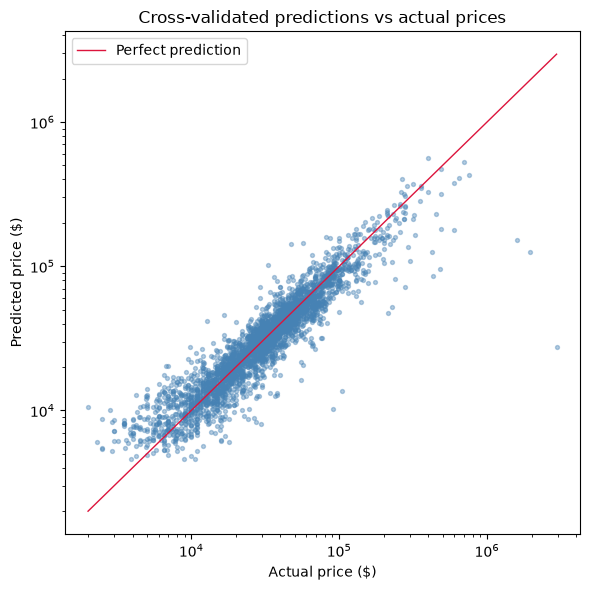

In [22]:
p_blend = (p_hgb + p_rf) / 2

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_train, p_blend, s=8, alpha=0.4, color='steelblue')
lims = [y_train.min(), y_train.max()]
ax.plot(lims, lims, color='crimson', linewidth=1, label='Perfect prediction')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Actual price ($)')
ax.set_ylabel('Predicted price ($)')
ax.set_title('Cross-validated predictions vs actual prices')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Final Training & Test Predictions

Both models are retrained on the **full** training set, and their predictions for the test set are averaged. The final check confirms there is exactly one prediction per test car.

In [23]:
hgb.fit(X_train, y_train)
rf.fit(X_train, y_train)

test_pred = (hgb.predict(X_test) + rf.predict(X_test)) / 2
print('Predictions:', len(test_pred), '| Test rows:', len(test))

Predictions: 802 | Test rows: 802


## 10. Save Predictions

Each test `id` is paired with its predicted price (rounded to the nearest dollar) and written to `predictions.csv`.

In [24]:
submission = pd.DataFrame({'id': test['id'], 'price': test_pred.round(0).astype(int)})
submission.to_csv('predictions.csv', index=False)
submission.head()

,id,price
0,3208,32984
1,3209,26625
2,3210,19363
3,3211,31795
4,3212,14280


## 11. Conclusion

**Conclusion**

- Careful cleaning kept every row of both datasets, including electric vehicles that have no fuel-type or cylinder information.
- Modelling log(price) reduced the extreme skew in the target.
- Target encoding allowed the high-cardinality `brand` and `model` columns to be used without overfitting.
- The blended Gradient Boosting and Random Forest model achieves a cross-validated MAE of about $11,000 and $R^2$ of 0.79 on cars under $500k.
